<img src="./logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico N°6
#### Yugra Yoseli
### 1er Cuatrimestre 2026

## Consigna

Dado las siguientes ecuaciones en diferencias de los siguientes sistemas, que representan un filtro de media móvil:

a) $y(n) = x(n-3) + x(n-2) + x(n-1) + x(n)$

b) $y(n) = x(n-4) + x(n-3) + x(n-2) + x(n-1) + x(n)$

c) $y(n) = x(n) - x(n-1)$

d) $y(n) = x(n) - x(n-2)$

**Se pide:**

1. Hallar $T(z) = \dfrac{Y(z)}{X(z)}$
2. Calcular su respuesta en frecuencia de módulo y fase.
3. Simular y validar la respuesta en frecuencia de todos los sistemas con Numpy.

## Introducción

En este trabajo se analizan cuatro sistemas LTI descriptos por sus ecuaciones en diferencias. Para cada uno se obtiene la función de transferencia $T(z)$ aplicando la transformada Z, aprovechando la propiedad de desplazamiento temporal: $x(n-k) \leftrightarrow z^{-k} X(z)$.

A partir de $T(z)$, se calcula la respuesta en frecuencia reemplazando $z = e^{j\omega}$, donde $\omega$ es la frecuencia digital normalizada en radianes. El módulo se obtiene factorizando el término central para poder aplicar las identidades trigonométricas $e^{j\theta} + e^{-j\theta} = 2\cos(\theta)$ y $e^{j\theta} - e^{-j\theta} = 2j\sin(\theta)$.

Finalmente, los resultados analíticos se validan numéricamente usando `numpy` y `scipy`.

## Puntos 1 y 2 — Resolución a mano

En principio se comienza mostrando la resolución a mano de los ejercicios.

In [1]:
from IPython.display import IFrame

url_pdf = "https://raw.githubusercontent.com/yoseyugra/aps/main/ts6_Yugra_yoseli.pdf"
visor_google = f"https://docs.google.com/gview?url={url_pdf}&embedded=true"

IFrame(visor_google, width=1000, height=800)

## Punto 3 — Simulación y validación con Numpy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

w = np.linspace(0, np.pi, 1000)

### Sistema a)

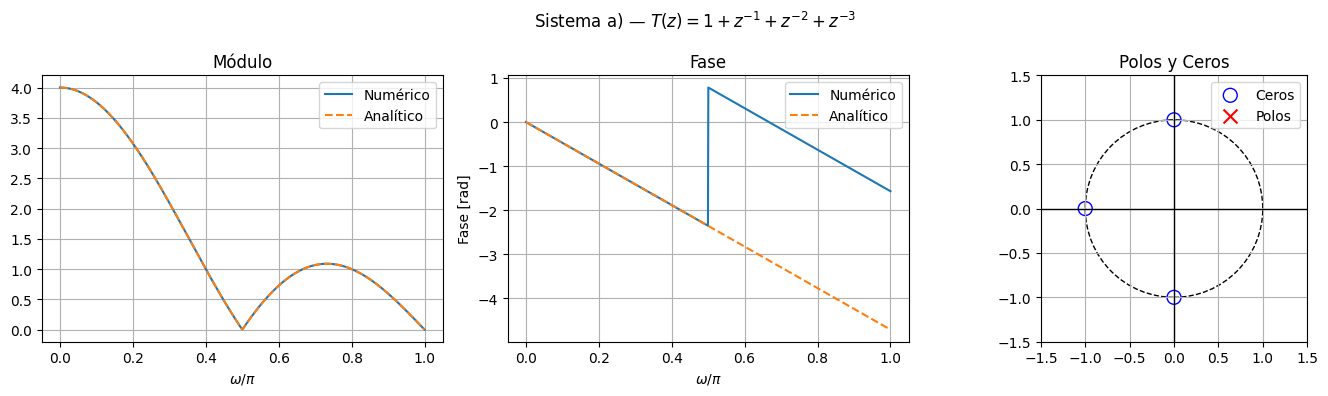

In [14]:
b_a = np.array([1, 1, 1, 1])
w_a, H_a = sig.freqz(b_a, [1], worN=w)

# respuesta analítica — pasa bajos, ganancia máxima en omega=0
mod_a  = 2 * np.abs(np.cos(3*w/2) + np.cos(w/2))
fase_a = -3*w/2

ceros_a, polos_a, _ = sig.tf2zpk(b_a, [1])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), tight_layout=True)
fig.suptitle(r"Sistema a) — $T(z) = 1 + z^{-1} + z^{-2} + z^{-3}$")

# módulo
axes[0].plot(w/np.pi, np.abs(H_a), label='Numérico')
axes[0].plot(w/np.pi, mod_a, '--', label='Analítico')
axes[0].set_xlabel(r'$\omega / \pi$')
axes[0].set_title('Módulo')
axes[0].legend(); axes[0].grid(True)

# fase lineal — típico de filtros FIR simétricos, pendiente -3/2
axes[1].plot(w/np.pi, np.unwrap(np.angle(H_a)), label='Numérico')
axes[1].plot(w/np.pi, fase_a, '--', label='Analítico')
axes[1].set_xlabel(r'$\omega / \pi$')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase')
axes[1].legend(); axes[1].grid(True)

# polos y ceros — ceros sobre el círculo unitario
circulo = plt.Circle((0, 0), 1, color='k', fill=False, linestyle='--')
axes[2].add_patch(circulo)
axes[2].scatter(np.real(ceros_a), np.imag(ceros_a), s=100, marker='o',
                facecolors='none', edgecolors='b', label='Ceros')
axes[2].scatter(np.real(polos_a), np.imag(polos_a), s=100, marker='x',
                color='r', label='Polos')
axes[2].axhline(0, color='k', lw=1)
axes[2].axvline(0, color='k', lw=1)
axes[2].set_xlim([-1.5, 1.5]); axes[2].set_ylim([-1.5, 1.5])
axes[2].set_aspect('equal')
axes[2].set_title('Polos y Ceros')
axes[2].legend(); axes[2].grid(True)

plt.show()

El módulo numérico y analítico coinciden exactamente. Es un filtro pasa-bajos con ganancia máxima en $\omega = 0$ y fase lineal con pendiente $-3/2$, típico de filtros FIR simétricos. Los ceros están sobre el círculo unitario, lo que confirma que el filtro atenúa completamente ciertas frecuencias.

### Sistema b)

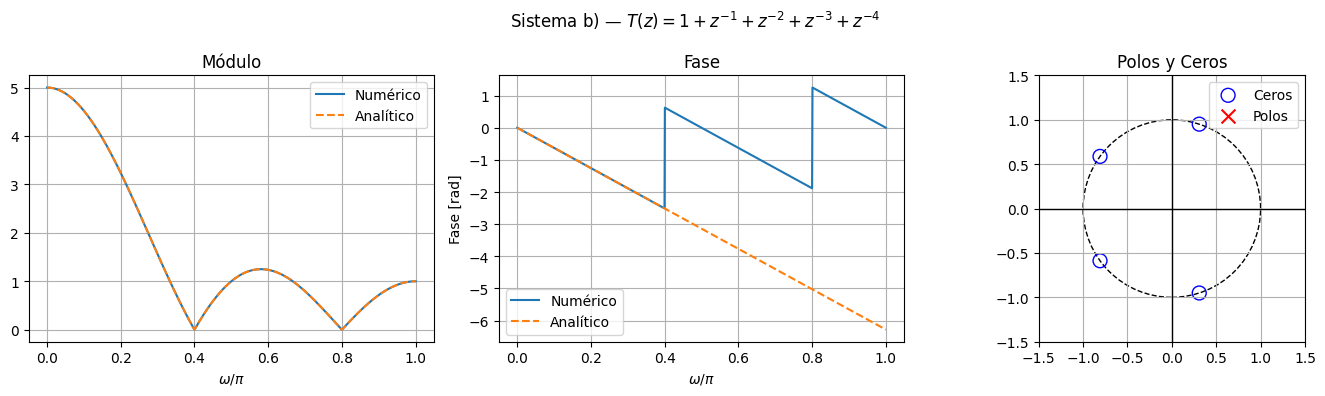

In [11]:
b_b = np.array([1, 1, 1, 1, 1])
w_b, H_b = sig.freqz(b_b, [1], worN=w)

# respuesta analítica
mod_b  = np.abs(2*np.cos(2*w) + 2*np.cos(w) + 1)
fase_b = -2*w

ceros_b, polos_b, _ = sig.tf2zpk(b_b, [1])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), tight_layout=True)
fig.suptitle(r"Sistema b) — $T(z) = 1 + z^{-1} + z^{-2} + z^{-3} + z^{-4}$")

# módulo
axes[0].plot(w/np.pi, np.abs(H_b), label='Numérico')
axes[0].plot(w/np.pi, mod_b, '--', label='Analítico')
axes[0].set_xlabel(r'$\omega / \pi$')
axes[0].set_title('Módulo')
axes[0].legend(); axes[0].grid(True)

# fase
axes[1].plot(w/np.pi, np.unwrap(np.angle(H_b)), label='Numérico')
axes[1].plot(w/np.pi, fase_b, '--', label='Analítico')
axes[1].set_xlabel(r'$\omega / \pi$')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase')
axes[1].legend(); axes[1].grid(True)

# polos y ceros
circulo = plt.Circle((0, 0), 1, color='k', fill=False, linestyle='--')
axes[2].add_patch(circulo)
axes[2].scatter(np.real(ceros_b), np.imag(ceros_b), s=100, marker='o',
                facecolors='none', edgecolors='b', label='Ceros')
axes[2].scatter(np.real(polos_b), np.imag(polos_b), s=100, marker='x',
                color='r', label='Polos')
axes[2].axhline(0, color='k', lw=1)
axes[2].axvline(0, color='k', lw=1)
axes[2].set_xlim([-1.5, 1.5]); axes[2].set_ylim([-1.5, 1.5])
axes[2].set_aspect('equal')
axes[2].set_title('Polos y Ceros')
axes[2].legend(); axes[2].grid(True)

plt.show()

El sistema b) tiene el lóbulo principal más angosto que a) por tener más muestras (5 vs 4). La fase es lineal con pendiente $-2$, correspondiente a un retardo de grupo de 2 muestras. Tiene más ceros sobre el círculo unitario que a), lo que genera más atenuaciones en frecuencia.

### Sistema c)

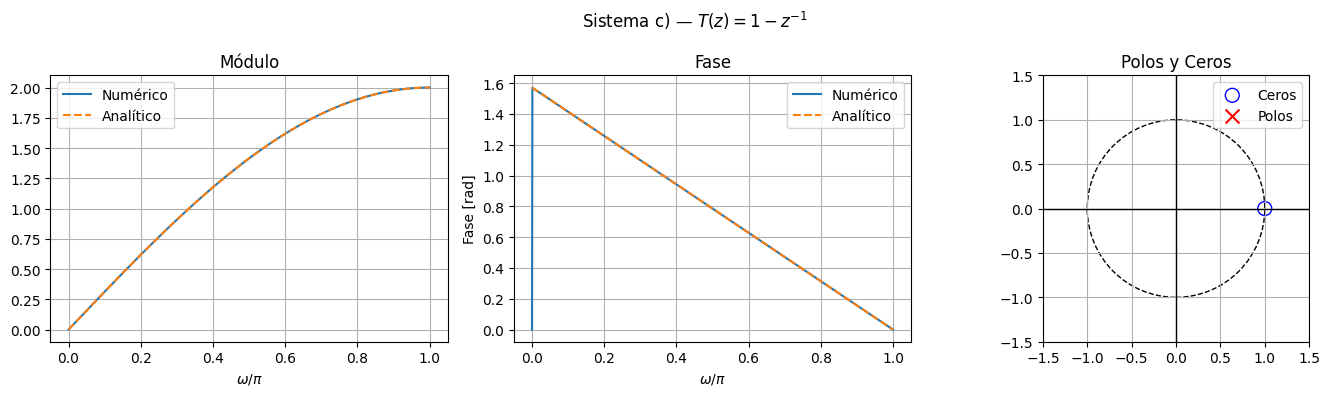

In [12]:
b_c = np.array([1, -1])
w_c, H_c = sig.freqz(b_c, [1], worN=w)

# respuesta analítica — pasa altos, cero en omega=0
mod_c  = 2 * np.abs(np.sin(w/2))
fase_c = np.pi/2 - w/2

ceros_c, polos_c, _ = sig.tf2zpk(b_c, [1])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), tight_layout=True)
fig.suptitle(r"Sistema c) — $T(z) = 1 - z^{-1}$")

# módulo
axes[0].plot(w/np.pi, np.abs(H_c), label='Numérico')
axes[0].plot(w/np.pi, mod_c, '--', label='Analítico')
axes[0].set_xlabel(r'$\omega / \pi$')
axes[0].set_title('Módulo')
axes[0].legend(); axes[0].grid(True)

# fase — offset de pi/2 por el j que aparece en la identidad del seno
axes[1].plot(w/np.pi, np.unwrap(np.angle(H_c)), label='Numérico')
axes[1].plot(w/np.pi, fase_c, '--', label='Analítico')
axes[1].set_xlabel(r'$\omega / \pi$')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase')
axes[1].legend(); axes[1].grid(True)

# polos y ceros
circulo = plt.Circle((0, 0), 1, color='k', fill=False, linestyle='--')
axes[2].add_patch(circulo)
axes[2].scatter(np.real(ceros_c), np.imag(ceros_c), s=100, marker='o',
                facecolors='none', edgecolors='b', label='Ceros')
axes[2].scatter(np.real(polos_c), np.imag(polos_c), s=100, marker='x',
                color='r', label='Polos')
axes[2].axhline(0, color='k', lw=1)
axes[2].axvline(0, color='k', lw=1)
axes[2].set_xlim([-1.5, 1.5]); axes[2].set_ylim([-1.5, 1.5])
axes[2].set_aspect('equal')
axes[2].set_title('Polos y Ceros')
axes[2].legend(); axes[2].grid(True)

plt.show()

El sistema c) es un filtro pasa-altos: tiene un cero en $z=1$ ($\omega=0$) que atenúa la continua. La fase tiene un offset de $\pi/2$ por el factor $j$ que aparece al desarrollar la identidad del seno.

### Sistema d)

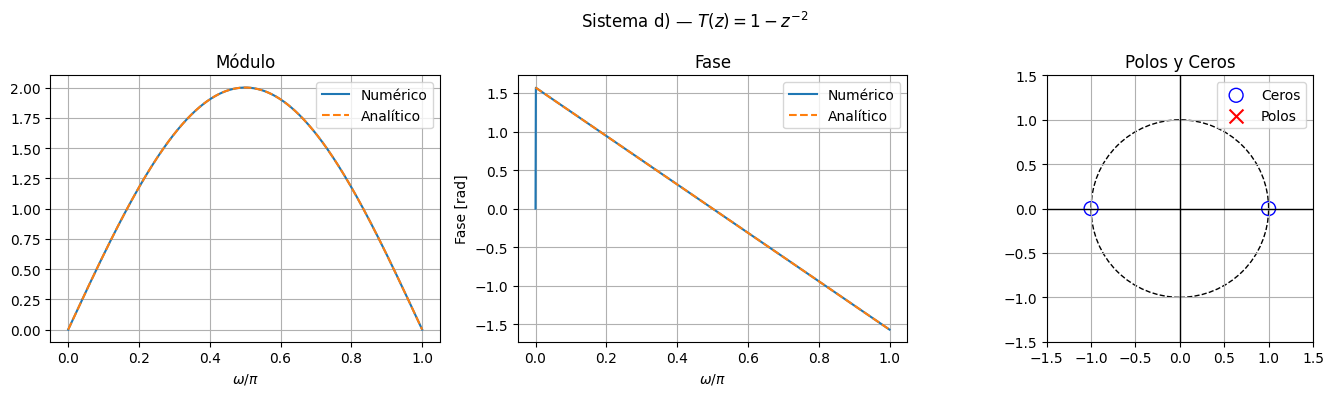

In [13]:
b_d = np.array([1, 0, -1])
w_d, H_d = sig.freqz(b_d, [1], worN=w)

# respuesta analítica — pasa banda, ceros en omega=0 y omega=pi
mod_d  = 2 * np.abs(np.sin(w))
fase_d = np.pi/2 - w

ceros_d, polos_d, _ = sig.tf2zpk(b_d, [1])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), tight_layout=True)
fig.suptitle(r"Sistema d) — $T(z) = 1 - z^{-2}$")

# módulo
axes[0].plot(w/np.pi, np.abs(H_d), label='Numérico')
axes[0].plot(w/np.pi, mod_d, '--', label='Analítico')
axes[0].set_xlabel(r'$\omega / \pi$')
axes[0].set_title('Módulo')
axes[0].legend(); axes[0].grid(True)

# fase — retardo de grupo de 1 muestra, pendiente el doble que c)
axes[1].plot(w/np.pi, np.unwrap(np.angle(H_d)), label='Numérico')
axes[1].plot(w/np.pi, fase_d, '--', label='Analítico')
axes[1].set_xlabel(r'$\omega / \pi$')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase')
axes[1].legend(); axes[1].grid(True)

# polos y ceros
circulo = plt.Circle((0, 0), 1, color='k', fill=False, linestyle='--')
axes[2].add_patch(circulo)
axes[2].scatter(np.real(ceros_d), np.imag(ceros_d), s=100, marker='o',
                facecolors='none', edgecolors='b', label='Ceros')
axes[2].scatter(np.real(polos_d), np.imag(polos_d), s=100, marker='x',
                color='r', label='Polos')
axes[2].axhline(0, color='k', lw=1)
axes[2].axvline(0, color='k', lw=1)
axes[2].set_xlim([-1.5, 1.5]); axes[2].set_ylim([-1.5, 1.5])
axes[2].set_aspect('equal')
axes[2].set_title('Polos y Ceros')
axes[2].legend(); axes[2].grid(True)

plt.show()

El sistema d) tiene ceros en $z=1$ y $z=-1$ ($\omega=0$ y $\omega=\pi$), con ganancia máxima en $\omega=\pi/2$. Es un filtro pasa-banda centrado en la mitad del espectro.

### Comparación de los 4 sistemas

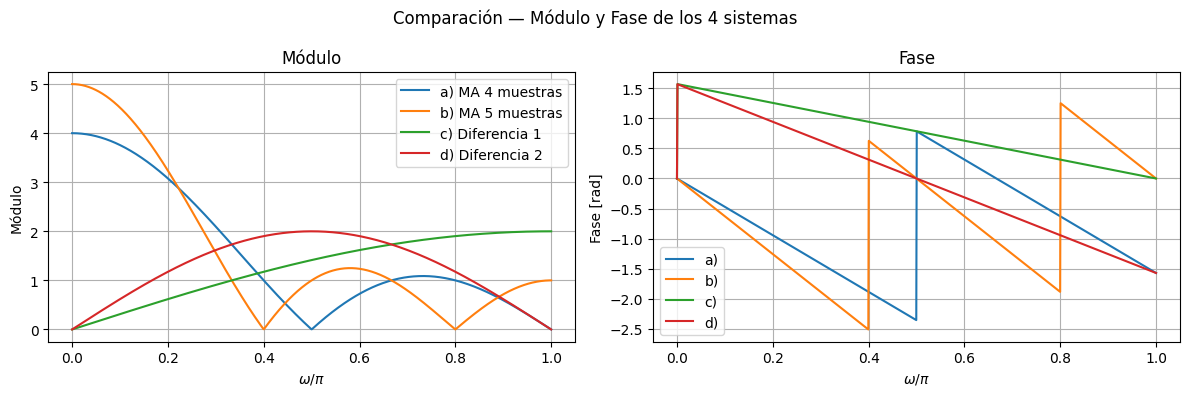

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
fig.suptitle("Comparación — Módulo y Fase de los 4 sistemas")

# módulo de los 4 sistemas superpuestos
ax1.plot(w/np.pi, np.abs(H_a), label='a) MA 4 muestras')
ax1.plot(w/np.pi, np.abs(H_b), label='b) MA 5 muestras')
ax1.plot(w/np.pi, np.abs(H_c), label='c) Diferencia 1')
ax1.plot(w/np.pi, np.abs(H_d), label='d) Diferencia 2')
ax1.set_xlabel(r'$\omega / \pi$')
ax1.set_ylabel('Módulo')
ax1.set_title('Módulo')
ax1.legend(); ax1.grid(True)

# fase de los 4 sistemas — todos tienen fase lineal
ax2.plot(w/np.pi, np.unwrap(np.angle(H_a)), label='a)')
ax2.plot(w/np.pi, np.unwrap(np.angle(H_b)), label='b)')
ax2.plot(w/np.pi, np.unwrap(np.angle(H_c)), label='c)')
ax2.plot(w/np.pi, np.unwrap(np.angle(H_d)), label='d)')
ax2.set_xlabel(r'$\omega / \pi$')
ax2.set_ylabel('Fase [rad]')
ax2.set_title('Fase')
ax2.legend(); ax2.grid(True)

plt.show()

Los sistemas a) y b) son pasa-bajos (media móvil), mientras que c) y d) son pasa-altos o pasa-banda. Todos tienen fase lineal, confirmando que son filtros FIR simétricos con retardo de grupo constante.

## Conclusión

Se analizaron cuatro sistemas LTI mediante la transformada Z y la evaluación de su respuesta en frecuencia. En todos los casos se obtuvo la función de transferencia $T(z)$ directamente de la ecuación en diferencias, aplicando la propiedad de retardo temporal.

Los sistemas a) y b) son pasa-bajos (media móvil), mientras que c) y d) son pasa-altos o pasa-banda. En todos los casos hubo una muy buena coincidencia entre los resultados analíticos y numéricos, validando los desarrollos realizados. Además, el análisis de polos y ceros permitió relacionar directamente las frecuencias atenuadas con la ubicación de los ceros sobre el círculo unitario. Todos los filtros presentan fase lineal y retardo de grupo constante, característica de filtros FIR con coeficientes simétricos o antisimétricos.